# ISMN Data Exploration
Visualising soil moisture data across stations.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_DIR = '../data/ismn_data'

In [15]:
# Load a single station
def load_station(network, station):
    path = os.path.join(DATA_DIR, network, f'{station}.csv')
    df = pd.read_csv(path, parse_dates=['datetime_utc'])
    df = df[df['ismn_flag_good'] == True]  # only good quality readings
    df = df.sort_values('datetime_utc')
    return df

# List all available stations
stations = []
for network in os.listdir(DATA_DIR):
    net_path = os.path.join(DATA_DIR, network)
    if os.path.isdir(net_path):
        for f in os.listdir(net_path):
            if f.endswith('.csv'):
                stations.append((network, f[:-4]))

print(f'{len(stations)} stations available:')
for n, s in stations:
    print(f'  {n} / {s}')

48 stations available:
  COSMOS / Mpala_North
  COSMOS / KLEE
  TAHMO / Kisasi_Primary_School_-_KCCA
  TAHMO / Ggaba_Demonstration_Primary_School_-_KCCA
  TAHMO / Senchura_Secondary_School
  TAHMO / Magomano_Secondary_School
  TAHMO / Kibisi_Secondary_School
  TAHMO / Longisa_High_School
  TAHMO / ES_Nyange
  TAHMO / Dedan_Kimathi_University_of_Technology
  TAHMO / GS_St_Pierre_Nkombo
  TAHMO / Moi_Forces_Academy
  TAHMO / Kibanda_Hydromet
  TAHMO / Nakivubo_Blue_Primary_School
  TAHMO / Dwa_Estate
  TAHMO / Maseno_University
  TAHMO / University_of_Embu
  TAHMO / Kibabii_University
  TAHMO / Sembabule_District_HQ_-_CHAI
  TAHMO / Imurtott_Primary_school
  TAHMO / ES_Kigoma
  TAHMO / NDMA-Tana_River_Hola
  TAHMO / Semuto_-_CHAI
  TAHMO / Lariak_Secondary_School
  TAHMO / Mateete_Subcounty_Sembabule_-_CHAI
  TAHMO / Apakope_Kayove
  TAHMO / Kibaale_Bridge-Rakai_CHAI
  TAHMO / College_de_Rushaki
  TAHMO / IPRC_Musanze
  TAHMO / Kyambogo_Primary_School_-_KCCA
  TAHMO / Naboisho_Camp
  TAH

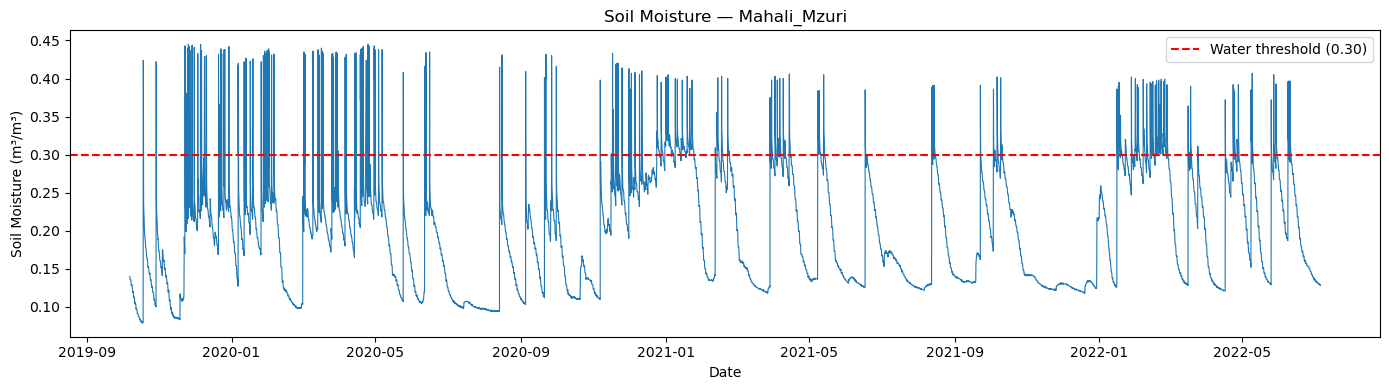

In [16]:
# Plot soil moisture over time for one station
network, station = 'TAHMO', 'Mahali_Mzuri'  # change this to any station

df = load_station(network, station)

plt.figure(figsize=(14, 4))
plt.plot(df['datetime_utc'], df['sm_value'], linewidth=0.8)
plt.axhline(0.30, color='red', linestyle='--', label='Water threshold (0.30)')
plt.title(f'Soil Moisture — {station}')
plt.xlabel('Date')
plt.ylabel('Soil Moisture (m³/m³)')
plt.legend()
plt.tight_layout()
plt.show()

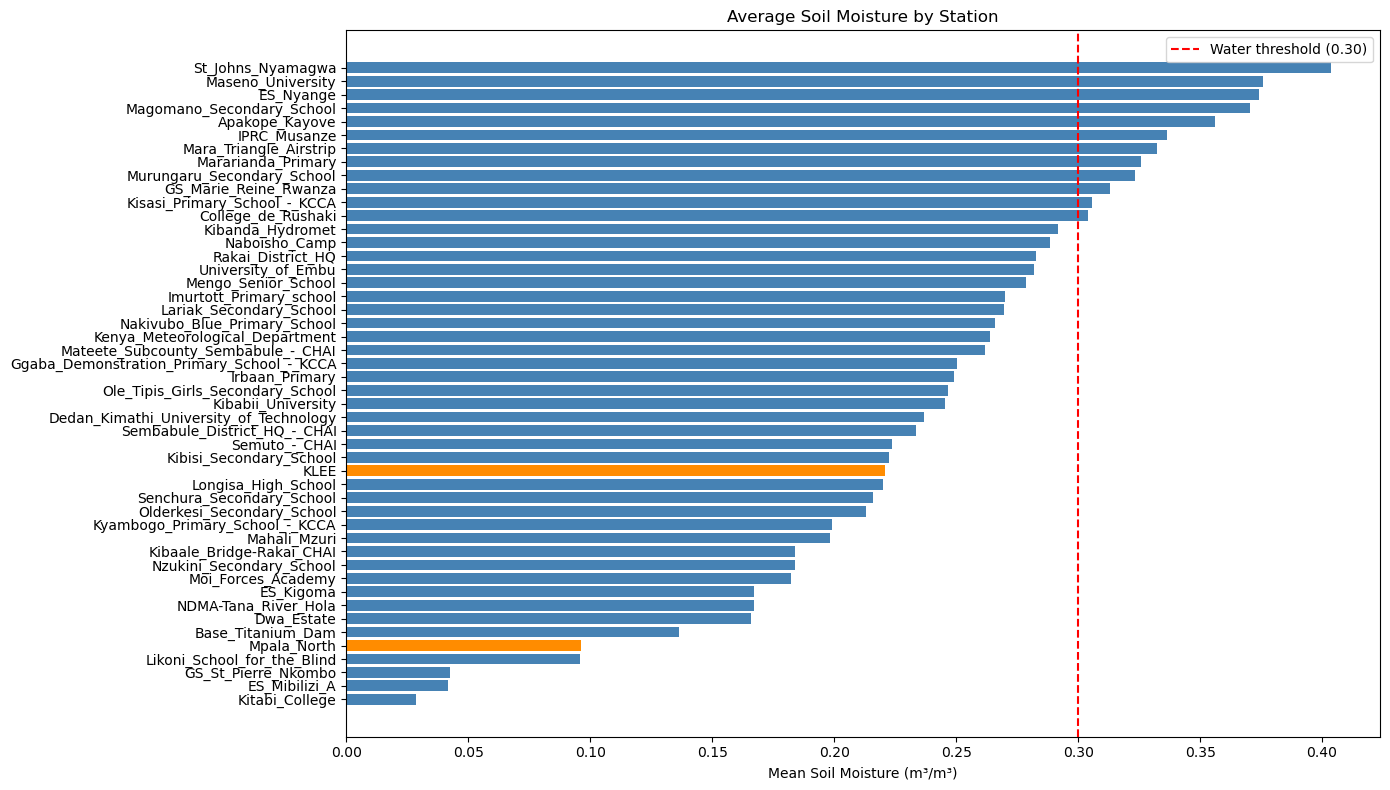

In [17]:
# Compare average soil moisture across all stations
summary = []
for network, station in stations:
    df = load_station(network, station)
    if len(df) > 0:
        summary.append({
            'station': station,
            'network': network,
            'mean_sm': df['sm_value'].mean(),
            'n_readings': len(df)
        })

summary_df = pd.DataFrame(summary).sort_values('mean_sm')

plt.figure(figsize=(14, 8))
colors = ['steelblue' if n == 'TAHMO' else 'darkorange' for n in summary_df['network']]
plt.barh(summary_df['station'], summary_df['mean_sm'], color=colors)
plt.axvline(0.30, color='red', linestyle='--', label='Water threshold (0.30)')
plt.xlabel('Mean Soil Moisture (m³/m³)')
plt.title('Average Soil Moisture by Station')
plt.legend()
plt.tight_layout()
plt.show()

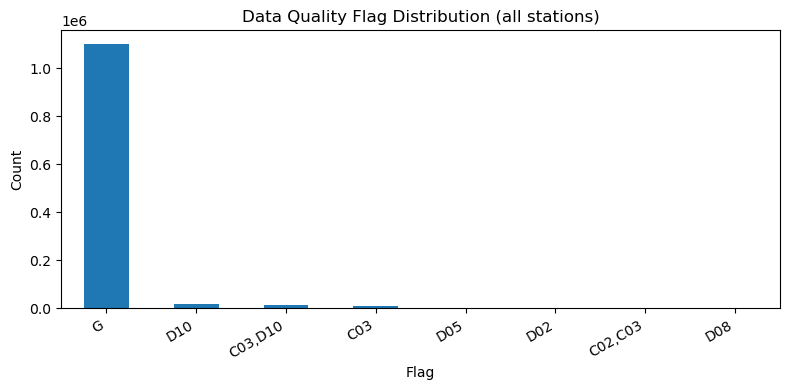

ismn_flag_raw
G          1103461
D10          19925
C03,D10      13979
C03           9181
D05           1288
D02            966
C02,C03        530
D08            375
Name: count, dtype: int64


In [19]:
# Flag quality breakdown across all data
all_flags = []
for network, station in stations:
    path = os.path.join(DATA_DIR, network, f'{station}.csv')
    df = pd.read_csv(path)
    all_flags.append(df['ismn_flag_raw'].value_counts())

flag_counts = pd.concat(all_flags).groupby(level=0).sum().sort_values(ascending=False)
flag_counts = flag_counts[flag_counts >= 100]  # drop negligible flags

plt.figure(figsize=(8, 4))
flag_counts.plot(kind='bar')
plt.title('Data Quality Flag Distribution (all stations)')
plt.xlabel('Flag')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(flag_counts)

In [ ]:
# Relationship between station characteristics and mean soil moisture
station_meta = []
for network, station in stations:
    path = os.path.join(DATA_DIR, network, f'{station}.csv')
    df = pd.read_csv(path)
    good = df[df['ismn_flag_good'] == True]
    if len(good) == 0:
        continue
    row = df.iloc[0]
    station_meta.append({
        'station':     station,
        'network':     network,
        'mean_sm':     good['sm_value'].mean(),
        'elevation_m': row['elevation_m'],
        'latitude':    row['latitude'],
        'longitude':   row['longitude'],
        'depth_m':     row['depth_from_m'],
    })

meta = pd.DataFrame(station_meta)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('elevation_m', 'Elevation (m)'),
    ('latitude',    'Latitude (°)'),
    ('depth_m',     'Sensor Depth (m)'),
]

for ax, (col, label) in zip(axes, pairs):
    colors = ['steelblue' if n == 'TAHMO' else 'darkorange' for n in meta['network']]
    ax.scatter(meta[col], meta['mean_sm'], c=colors, edgecolors='white', linewidths=0.5, s=60)
    ax.axhline(0.30, color='red', linestyle='--', linewidth=0.8, label='threshold')
    ax.set_xlabel(label)
    ax.set_ylabel('Mean Soil Moisture (m³/m³)')
    ax.set_title(f'Moisture vs {label}')

    corr = meta[[col, 'mean_sm']].dropna().corr().iloc[0, 1]
    ax.annotate(f'r = {corr:.2f}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=9)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',  markersize=8, label='TAHMO'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=8, label='COSMOS'),
    Line2D([0], [0], color='red', linestyle='--', label='threshold (0.30)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('What drives differences in mean soil moisture across stations?', y=1.02)
plt.tight_layout()
plt.show()